# Simulation 3 — Ring resonator Q-factor and FSR

A **ring resonator** filters wavelengths: on resonance the round-trip phase satisfies $2\\pi r n_{\\mathrm{eff}} = m\\lambda$. The transmission spectrum shows periodic notches with free spectral range $\\mathrm{FSR} \\approx \\lambda^2 / (n_g L)$ and linewidth set by coupling and loss (Q-factor).

We inject a broadband Gaussian pulse, record bus flux, and fit a Lorentzian to the deepest resonance.

In [2]:
import matplotlib.pyplot as plt
import tidy3d.web as web

from fdtd_pic.analytics.ring import analytical_fsr_hz, fit_resonance, measured_fsr
from fdtd_pic.config import RING_RADIUS
from fdtd_pic.plotting import apply_style, save_figure
from fdtd_pic.ring import build_ring_simulation, extract_transmission_spectrum

apply_style()

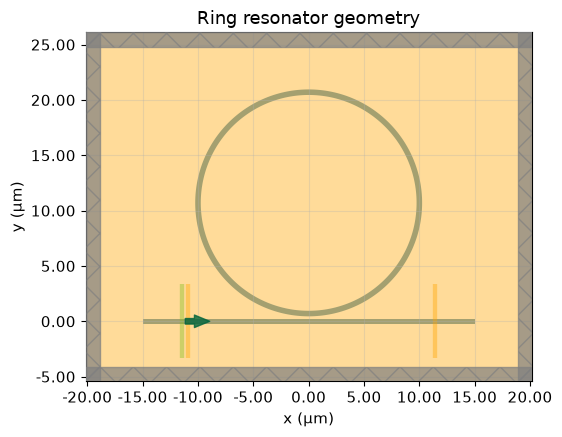

In [3]:
sim = build_ring_simulation()
sim.plot(z=0)
plt.title('Ring resonator geometry')
plt.show()


# ring gap at 3 0clock seems to be the way the polygons are defined, looking into a fix.
# fixed! - see commit 105cfae


# ahhhh i missed that the ring was clipped so the ring actually isnt connectted to itself, need to fix this and re-run

# think i fixed, waiting to commit.

15:32:45 UTC Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=13213019;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=13213020;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10\taskId]8;;\]8;id=13213019;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10\=]8;;\]8;id=13213021;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10\fdve]8;;\]8;id=13213019;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10\-d5651f47-924]8;;\
             ]8;id=13213019;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10\9-4eb9-bd7b-6622d80b4b10']8;;\.

15:32:46 UTC WARNING: Simulation final field decay value of 0.00385 is greater  
             than the simulation shutoff threshold of 1e-05. Consider running   
             the simulation again with a larger 'run_time' duration for more    
             accurate results.                                                  

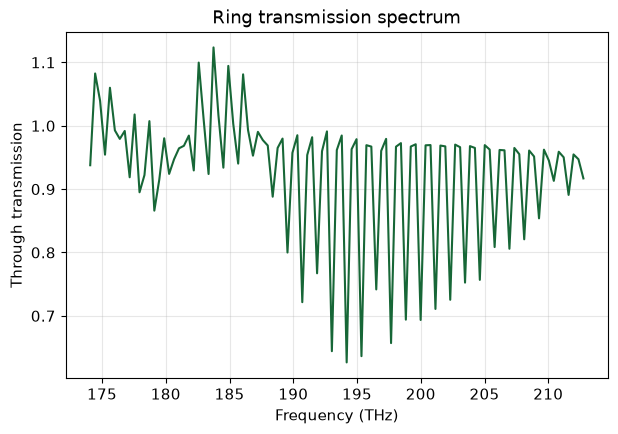

In [4]:
# simulating and web run

sim_data = web.run(sim, task_name='ring', verbose=True)
freqs, transmission = extract_transmission_spectrum(sim_data)

fig, ax = plt.subplots()
ax.plot(freqs / 1e12, transmission)
ax.set_xlabel('Frequency (THz)')
ax.set_ylabel('Through transmission')
ax.set_title('Ring transmission spectrum')
save_figure(fig, '../assets/ring_transmission_spectrum.png')
plt.show()

**Explanation (what i think) of figure above**

dip deths vary considerably, shallow up untill 187~THz, deeping untill 210THZ. - im thinking this is maybe due to the ring hosting different resonances which would differ in coupling strength or quality factor across the band?. --- dip depth is set by how close we are to critical coupling.

Broader envelope perhaps due to incomplete field decay, but a much larger simulation time would likely be required as we have a long lasting resonance? --- the fact that transmission is apparently >1 is a clear sign the simulation has not fully converged.

the 190 - 210 THz range is likely the high Q family.


Note on ring radius:

our 10 micron ring has little bend loss compared to ultra compact submicron PIC's. High Q -> slower enrgy decay, simulating untill field decay too expensive and not neccessary for this project.

FSR = c / (Ng * 2*pi*R) --- for silicon waveguides at our 1550nm wavelength, with a Ng approx 4.2, FSR would be likely 1.1 THz ---- **given we have 5 peaks in the 190 - 195 THz RANGE, THIS IS CONSISTENT WITH my SIMULATION**



In [5]:
sim_data = web.load(
    "fdve-d5651f47-9249-4eb9-bd7b-6622d80b4b10",
    path=".tidy3d_cache/ring.hdf5",
    verbose=True,
)

Output()

15:33:29 UTC Loading results from .tidy3d_cache/ring.hdf5

             WARNING: Simulation final field decay value of 0.00385 is greater  
             than the simulation shutoff threshold of 1e-05. Consider running   
             the simulation again with a larger 'run_time' duration for more    
             accurate results.                                                  

In [6]:
freqs, transmission = extract_transmission_spectrum(sim_data)

Using 59 points in selected band
Band: 187.225 – 209.661 THz
Resonance f0 = 197.991 THz
Q = 9
FSR (sim) ~ 1.1605 THz
FSR (analytical) ~ 1.1360 THz


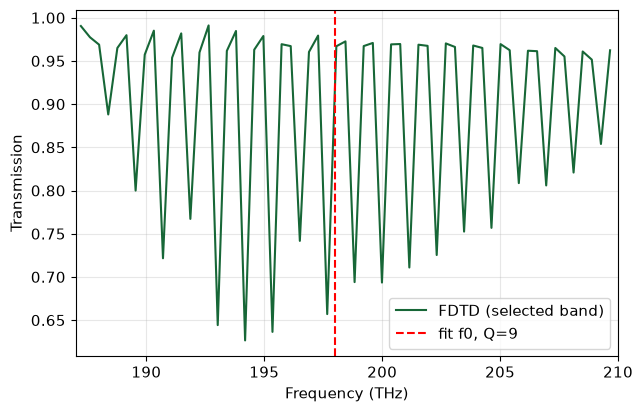

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from fdtd_pic.analytics.ring import analytical_fsr_hz, fit_resonance, measured_fsr
from fdtd_pic.config import RING_RADIUS
from fdtd_pic.plotting import save_figure

# --- choose your analysis window (pick one style) ---

# Style A: frequency in THz (easy to read)
f_min_thz = 187.0
f_max_thz = 210.0

mask = (freqs / 1e12 >= f_min_thz) & (freqs / 1e12 <= f_max_thz)

# Subset for analysis
freqs_win = freqs[mask]
trans_win = transmission[mask]

print(f"Using {freqs_win.size} points in selected band")
print(f"Band: {freqs_win.min()/1e12:.3f} – {freqs_win.max()/1e12:.3f} THz")

# Fit / FSR only inside window
fit = fit_resonance(freqs_win, trans_win)
fsr_sim = measured_fsr(freqs_win, trans_win)
fsr_analytical_hz = analytical_fsr_hz(RING_RADIUS)

print(f"Resonance f0 = {fit.f0/1e12:.3f} THz")
print(f"Q = {fit.q_factor:.0f}")
print(f"FSR (sim) ~ {fsr_sim/1e12:.4f} THz" if fsr_sim == fsr_sim else "FSR (sim): n/a")
print(f"FSR (analytical) ~ {fsr_analytical_hz/1e12:.4f} THz")

# Plot only window
fig, ax = plt.subplots()
ax.plot(freqs_win / 1e12, trans_win, label="FDTD (selected band)")
ax.axvline(fit.f0 / 1e12, color="r", ls="--", label=f"fit f0, Q={fit.q_factor:.0f}")
ax.set_xlim(f_min_thz, f_max_thz)   # optional if you used Style A
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Transmission")
ax.legend()
save_figure(fig, "../assets/ring_lorentzian_fit.png")
plt.show()

## Key takeaway -- Ignore Q, FSR more reasonable value currently

Fit is being pulled by ripples from a wide band --- not tracking one nice resonance peak....

linewidth: Q = 9 (???) and f_0 ~ 198THz, linewidth f_0/Q ~ 22THz -. NERLY 20X WIDER THAN fsr ~ 1.16 THz -- physically inconsistent for a real cavity resonance.

- Data points too coarse to window onto a small frequency region, would be pointless


## Second attempt, fixing issues seen above with clarity of resonant peaks - 7 credits, 3.8x previous



Finer frequency, properly fitted lorentzian (hopefully) to find Q

In [1]:
# --- imports & repo root ---
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web

from fdtd_pic.analytics.ring import fit_resonance, lorentzian
from fdtd_pic.config import (
    DEFAULT_WIDTH,
    FREQ0,
    FWIDTH,
    HEIGHT,
    PML_SPACING,
    RING_GAP,
    RING_RADIUS,
    WAVELENGTH,
)
from fdtd_pic.plotting import save_figure
from fdtd_pic.ring import extract_transmission_spectrum, make_ring_structures
from fdtd_pic.materials import sio2_medium

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    os.chdir(ROOT.parent)
print("cwd:", Path.cwd())



# --- knobs (edit these) ---
F0_HZ = 194e12          # from pass-1 broad fit (Hz)
DF_THZ = 1.0               # half-width of fine band (THz) → ±0.25 THz window
DF_STEP_THZ = 0.01          # frequency spacing (THz)- need high res 
RING_GAP_FINE = RING_GAP    # try 0.15 or 0.1 if dip is shallow
RUN_TIME_S = 1e-10          # tune so num_time_steps < 9e6
MIN_STEPS = 8
SHUTOFF = 1e-3              # on Simulation object (not web.run)
TASK_NAME = "ring_finer"
CACHE_PATH = Path(".tidy3d_cache") / f"{TASK_NAME}.hdf5"
MAX_STEPS = 9_000_000
MAX_EST_CREDITS = 10.0
FORCE_RERUN = True          # set False after one verified good run

# --- build fine-band simulation ---
def build_ring_simulation_fine(
    f_center_hz: float,
    *,
    df_thz: float = 0.25,
    df_step_thz: float = 0.03,
    radius: float = RING_RADIUS,
    gap: float = RING_GAP,
    width: float = DEFAULT_WIDTH,
    bus_length: float = 30.0,
    run_time: float = RUN_TIME_S,
    min_steps_per_wvl: int = MIN_STEPS,
    shutoff: float = SHUTOFF,
) -> td.Simulation:
    """Ring FDTD with dense flux/field monitors around one resonance."""
    f_min = f_center_hz - df_thz * 1e12
    f_max = f_center_hz + df_thz * 1e12
    freqs = np.arange(f_min, f_max + 1e6, df_step_thz * 1e12)  # +1e6 Hz avoids float edge miss
    if freqs.size < 5:
        raise ValueError(
            f"Only {freqs.size} frequency points — increase df_thz or decrease df_step_thz"
        )

    ring_center_y = radius + gap + width
    r_outer = radius + width / 2
    structures = make_ring_structures(radius=radius, gap=gap, width=width, bus_length=bus_length)

    y_min = min(-width / 2, ring_center_y - r_outer)
    y_max = max(width / 2, ring_center_y + r_outer)
    x_min = min(-bus_length / 2, -r_outer)
    x_max = max(bus_length / 2, r_outer)
    buffer = WAVELENGTH
    sim_x = (x_max - x_min) + 2 * PML_SPACING + buffer
    sim_y = (y_max - y_min) + 2 * PML_SPACING + buffer
    sim_z = HEIGHT + 2 * PML_SPACING
    sim_center = ((x_max + x_min) / 2, (y_max + y_min) / 2, 0.0)

    x_src = -bus_length / 2 + PML_SPACING + 0.5
    x_mon = bus_length / 2 - PML_SPACING - 0.5

    source_time = td.GaussianPulse(freq0=FREQ0, fwidth=FWIDTH)
    freq_list = [float(f) for f in freqs]

    source = td.ModeSource(
        center=(x_src, 0.0, 0.0),
        size=(0, width, sim_z),
        source_time=source_time,
        direction="+",
        mode_spec=td.ModeSpec(num_modes=1),
        name="source",
    )
    flux_in = td.FluxMonitor(
        center=(x_src + 0.5, 0.0, 0.0),
        size=(0, width, sim_z),
        freqs=freq_list,
        name="flux_in",
    )
    flux_out = td.FluxMonitor(
        center=(x_mon, 0.0, 0.0),
        size=(0, width, sim_z),
        freqs=freq_list,
        name="flux_out",
    )
    field_monitor = td.FieldMonitor(
        center=(0, (y_max + y_min) / 2, 0),
        size=(td.inf, td.inf, 0),
        freqs=freq_list,
        name="field_xy",
    )

    return td.Simulation(
        size=(sim_x, sim_y, sim_z),
        center=sim_center,
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=min_steps_per_wvl,
            wavelength=WAVELENGTH,
        ),
        structures=structures,
        sources=[source],
        monitors=[flux_in, flux_out, field_monitor],
        run_time=run_time,
        shutoff=shutoff,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        medium=sio2_medium(),
    )


def nearest_monitor_freq(sim_data: td.SimulationData, f_target_hz: float) -> float:
    freqs_avail = np.asarray(sim_data["field_xy"].Ey.f.values, dtype=float)
    idx = int(np.argmin(np.abs(freqs_avail - f_target_hz)))
    f_pick = float(freqs_avail[idx])
    print(f"nearest field freq to {f_target_hz/1e12:.4f} THz → {f_pick/1e12:.4f} THz")
    return f_pick

cwd: /workspaces/fdtd-pic-simulations


In [2]:
import os
from pathlib import Path
import tidy3d as td
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
CACHE = ".tidy3d_cache/ring_finer.hdf5"
sim_data_fine = td.SimulationData.from_file(
    CACHE,
    monitor_names=["flux_in", "flux_out"],  # skip heavy field_xy
)
from fdtd_pic.ring import extract_transmission_spectrum
freqs, transmission = extract_transmission_spectrum(sim_data_fine)
print(len(freqs), "points")
print(freqs.min()/1e12, "–", freqs.max()/1e12, "THz")

201 points
193.0 – 195.0 THz


In [3]:
fit = fit_resonance(freqs, transmission)
T_min = float(transmission.min())
T_max = float(transmission.max())
extinction_db = -10.0 * np.log10(max(T_min, 1e-12) / max(T_max, 1e-12))
wl_res_um = 299_792_458.0 / fit.f0 * 1e6

print(f"Resonance f0 = {fit.f0 / 1e12:.4f} THz  (λ ≈ {wl_res_um:.4f} µm)")
print(f"Q = {fit.q_factor:.0f}")
print(f"Dip: T_min={T_min:.4f}, T_max={T_max:.4f}, extinction≈{extinction_db:.2f} dB")

Resonance f0 = 194.8779 THz  (λ ≈ 1.5384 µm)
Q = 10684
Dip: T_min=0.3375, T_max=1.0812, extinction≈5.06 dB


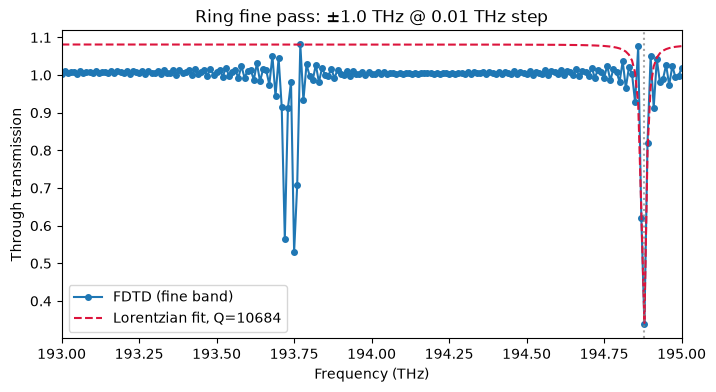

In [4]:
T_fit = T_max - lorentzian(freqs, fit.f0, fit.gamma, fit.amplitude)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freqs / 1e12, transmission, "o-", ms=4, label="FDTD (fine band)")
ax.plot(freqs / 1e12, T_fit, "--", color="crimson", label=f"Lorentzian fit, Q={fit.q_factor:.0f}")
ax.axvline(fit.f0 / 1e12, color="gray", ls=":", alpha=0.7)
ax.set_xlim(freqs.min() / 1e12, freqs.max() / 1e12)
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Through transmission")
ax.set_title(f"Ring fine pass: ±{DF_THZ} THz @ {DF_STEP_THZ} THz step")
ax.legend()
save_figure(fig, "assets/ring_fine_transmission.png")
plt.show()

## Ring field at resonance (Tidy3D web viewer)

on-resonance field magnitude from the fine-band simulation (193–195 THz).

<table>
<tr>
  <td align="center"><b>193.72 THz</b><br>
    <img src="../assets/193 ring pic.png" width="750">
  </td>
  <td align="center"><b>194.88 THz</b><br>
    <img src="../assets/194 ring pic.png" width="750">
  </td>
</tr>
<tr>
  <td align="center"><b>193.72 THz (animation)</b><br>
    <img src="../assets/193 ring gif.gif" width="750">
  </td>
  <td align="center"><b>194.88 THz (animation)</b><br>
    <img src="../assets/194 ring gif.gif" width="750">
  </td>
</tr>
</table>

# Ring Resonator Takeaway
Transmission spectrum shows our clean deep fitted ressonance(s) at ~194.88 THz, with a Q factor = 10684.
The field visual at this frequency (Right side of images above), shows our bright strognly excited ring --- This is consistent with energy build up.

The second "dip" that I saw on the transmssion graph in the 193.75 THz range peaked my interest as it was not well fitted / resolved and so with some tinkering i found on the tidy3d simulation that 193.72 THz was the most excited frequency of the ring. The dimmer field makes sense due to a smaller transmission dip,  hence less energy is coupled (less yellowy/white in colour compared to 194.88 THz).

I would improve this simulation by using a finer frequency gap so that modes like the 193.72 THz would be better approximated, but for this project I am happy with the current estimate there.

### A Couple of thoughts on the visuals above that were interesting to me...

The spatial pattern of both animations appear less dense at the top and bottom of the ring. Light of course enters at the bottom of both rings nearest to the waveguide, and then propagates around the ring. --- A small amount of energy us lost each round trip due to bend loss, maybe some sidewall scattering, and recoupling back to the "bus".

Perhaps the main effect being seen here is from back reflection causing a standing wave interference pattern? 

Maybe this is a effect soleley due to the framerate of both gifs but the fact that it is there on both makes me wonder. The images of magnitude (|E|) for both however show solid lines so im leaning towards this just being an artifact of the animation...

**Its good to probably mention here the animation for both is of the real part of the Ex field, when I investigated the real part of the Ey field for both, the thinning was on the left and right side, so this is simply a result of which component of the field i chose to take an animation off**

Final consensus: Artifact, not physics


### Apparent Flashing of fields in animations perhaps have no meaning too?

Yes, the flashing of the fields have no meaning. This is another artifact of the Ex animations as can be figured out by comparing to the time averaged magnitude plots for each.

